In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("/content/drive/MyDrive/DSBDL/Acedemic Performance.csv")

In [3]:
df.tail()

,id,mathsscore,readingscore,writingscore,placementscore,club joining date
45,46,84,85,83.0,78.0,12/06/2026
46,47,68,71,66.0,58.0,01/07/2026
47,48,90,92,91.0,87.0,15/07/2026
48,49,75,77,74.0,68.0,01/08/2026
49,50,82,84,81.0,76.0,10/08/2026


In [4]:
df.isnull().sum()

,0
id,0
mathsscore,0
readingscore,0
writingscore,1
placementscore,2
club joining date,0


In [5]:
df.isna().sum().sum()

np.int64(3)

In [6]:
df.loc[df["mathsscore"] > 100, "mathsscore"] = np.nan
df.loc[df["readingscore"] > 100, "readingscore"] = np.nan
df.loc[df["writingscore"] > 100, "writingscore"] = np.nan
df.loc[df["placementscore"] > 100, "placementscore"] = np.nan


In [7]:
df["writingscore"] = df["writingscore"].fillna(df["writingscore"].median())

In [8]:
df.isna().sum()

,0
id,0
mathsscore,1
readingscore,1
writingscore,0
placementscore,2
club joining date,0


In [9]:
df["placementscore"] = df["placementscore"].fillna(df["placementscore"].median())

In [10]:
df.isnull().sum()

,0
id,0
mathsscore,1
readingscore,1
writingscore,0
placementscore,0
club joining date,0


In [11]:
df["mathsscore"] = df["mathsscore"].fillna(df["mathsscore"].median())
df["readingscore"] = df["readingscore"].fillna(df["readingscore"].median())

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nColumn: {col}")
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Outliers Found:", len(outliers))


Column: id
Lower Bound: -23.5
Upper Bound: 74.5
Outliers Found: 0

Column: mathsscore
Lower Bound: 45.0
Upper Bound: 115.0
Outliers Found: 0

Column: readingscore
Lower Bound: 51.375
Upper Bound: 114.375
Outliers Found: 0

Column: writingscore
Lower Bound: 43.625
Upper Bound: 114.625
Outliers Found: 0

Column: placementscore
Lower Bound: 32.5
Upper Bound: 114.5
Outliers Found: 0


In [14]:
df["placementscore"].skew()

np.float64(-0.03400109281623204)

In [15]:
df["placementscore_1to10"] = (df["placementscore"] / 10).round(0)

In [16]:
df.head()

,id,mathsscore,readingscore,writingscore,placementscore,club joining date,placementscore_1to10
0,1,85.0,92.0,88.0,78.0,01/09/2024,8.0
1,2,72.0,81.0,75.0,65.0,05/09/2024,6.0
2,3,95.0,98.0,97.0,90.0,15/09/2024,9.0
3,4,68.0,75.0,70.0,62.0,01/10/2024,6.0
4,5,88.0,85.0,91.0,82.0,10/10/2024,8.0


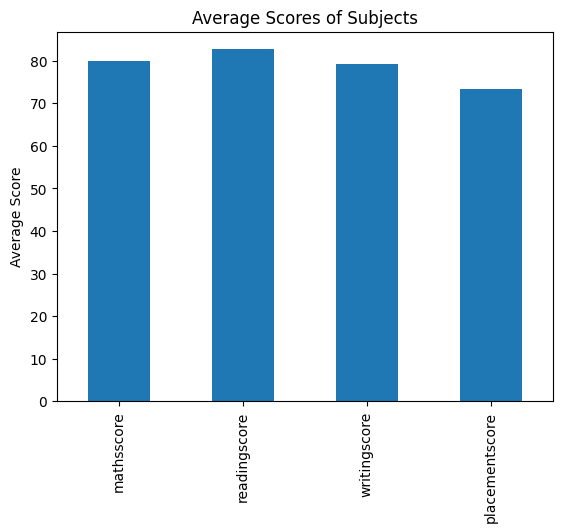

In [17]:
import matplotlib.pyplot as plt

avg_scores = df[["mathsscore","readingscore","writingscore","placementscore"]].mean()

avg_scores.plot(kind="bar")

plt.title("Average Scores of Subjects")
plt.ylabel("Average Score")
plt.show()
